# 06 Template Fraud Detector

**Project:** Insurance Fraud Detection Assistant

**Notebook:** `06-template-fraud-detector.ipynb`

In [2]:
# ==========================================
# Notebook 06
# Template Fraud Detector
# ==========================================

import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

d:\Books\projects-nlp-transformers-learning\.projectnlps\Lib\site-packages\sentence_transformers\cross_encoder\CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [3]:
claims_df = pd.read_csv("../data/insurance_claims.csv")

In [4]:
claims_df.head()

,claim_id,claimant_name,vehicle_vin,mechanic_shop,clinic_name,lawyer,claimant_statement,police_report,adjuster_notes,medical_bill,fraud_label
0,CLM001,Wendy Holland,FqH15433919443,Rapid Auto Repair,Care First Clinic,Smith & Associates,A vehicle rear-ended me while I was waiting at...,Witnesses confirmed another driver caused the ...,Section international though many movement.,5072,0
1,CLM002,Douglas Lara,acF49501195178,Rapid Auto Repair,Wellness Recovery Center,Anderson Legal,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Budget Mrs part spend middle threat smile incr...,1541,0
2,CLM003,Chloe Murphy,xeQ24677572737,Rapid Auto Repair,Care First Clinic,Justice Partners,I was stopped at a red light when another vehi...,Accident report indicates claimant followed tr...,Similar never box line.,20226,1
3,CLM004,Jodi Reynolds MD,sPL40843321198,Rapid Auto Repair,Wellness Recovery Center,Justice Partners,The vehicle changed lanes unexpectedly and hit...,Police observed damage consistent with reporte...,Section season nor political bank.,7723,0
4,CLM005,Elizabeth Patel,mmr35740163797,Prime Vehicle Repair,Wellness Recovery Center,Smith & Associates,I was driving through an intersection when ano...,Witnesses confirmed another driver caused the ...,Kind compare across audience society.,23376,0


In [5]:
embedding_model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2")

In [6]:
claim_embeddings = embedding_model.encode(
    claims_df["claimant_statement"].tolist(), show_progress_bar=True
)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [7]:
claim_embeddings.shape

(15, 768)

In [8]:
similarity_matrix = cosine_similarity(claim_embeddings)

In [10]:
pd.DataFrame(similarity_matrix)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,1.000000,0.714800,0.761848,0.714800,0.748067,0.433312,0.748067,0.646639,0.716063,0.748067,0.433312,0.716063,1.000000,0.646639,0.748067
1,0.714800,1.000000,0.698887,1.000000,0.863661,0.503276,0.863661,0.681408,0.777246,0.863661,0.503276,0.777246,0.714800,0.681408,0.863661
2,0.761848,0.698887,1.000000,0.698887,0.753231,0.431958,0.753231,0.637824,0.674216,0.753231,0.431958,0.674216,0.761848,0.637824,0.753231
3,0.714800,1.000000,0.698887,1.000000,0.863661,0.503276,0.863661,0.681408,0.777246,0.863661,0.503276,0.777246,0.714800,0.681408,0.863661
4,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000
5,0.433312,0.503276,0.431958,0.503276,0.588507,1.000000,0.588507,0.428851,0.414034,0.588507,1.000000,0.414034,0.433312,0.428851,0.588507
6,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000
7,0.646639,0.681408,0.637824,0.681408,0.692134,0.428851,0.692134,1.000000,0.654495,0.692134,0.428851,0.654495,0.646639,1.000000,0.692134
8,0.716063,0.777246,0.674216,0.777246,0.740162,0.414034,0.740162,0.654495,1.000000,0.740162,0.414034,1.000000,0.716063,0.654495,0.740162
9,0.748067,0.863661,0.753231,0.863661,1.000000,0.588507,1.000000,0.692134,0.740162,1.000000,0.588507,0.740162,0.748067,0.692134,1.000000


In [11]:
similarity_pairs = []

In [12]:
for i in range(len(claims_df)):

    for j in range(i + 1, len(claims_df)):

        similarity_pairs.append(
            {
                "claim_1": claims_df.iloc[i]["claim_id"],
                "claim_2": claims_df.iloc[j]["claim_id"],
                "claimant_1": claims_df.iloc[i]["claimant_name"],
                "claimant_2": claims_df.iloc[j]["claimant_name"],
                "similarity": similarity_matrix[i][j],
            }
        )

In [13]:
pairs_df = pd.DataFrame(similarity_pairs)

In [14]:
pairs_df.head()

,claim_1,claim_2,claimant_1,claimant_2,similarity
0,CLM001,CLM002,Wendy Holland,Douglas Lara,0.714800
1,CLM001,CLM003,Wendy Holland,Chloe Murphy,0.761848
2,CLM001,CLM004,Wendy Holland,Jodi Reynolds MD,0.714800
3,CLM001,CLM005,Wendy Holland,Elizabeth Patel,0.748067
4,CLM001,CLM006,Wendy Holland,Kevin Paul,0.433312


In [15]:
pairs_df.sort_values(by="similarity", ascending=False).head(20)

,claim_1,claim_2,claimant_1,claimant_2,similarity
59,CLM005,CLM015,Elizabeth Patel,Patricia Lopez,1.000000
94,CLM010,CLM015,Julia Wilson,Patricia Lopez,1.000000
54,CLM005,CLM010,Elizabeth Patel,Julia Wilson,1.000000
51,CLM005,CLM007,Elizabeth Patel,Lisa Rich,1.000000
71,CLM007,CLM010,Lisa Rich,Julia Wilson,1.000000
76,CLM007,CLM015,Lisa Rich,Patricia Lopez,1.000000
15,CLM002,CLM004,Douglas Lara,Jodi Reynolds MD,1.000000
64,CLM006,CLM011,Kevin Paul,Patrick Harvey,1.000000
11,CLM001,CLM013,Wendy Holland,Janice Zavala,1.000000
82,CLM008,CLM014,Pamela Hayes,Misty Smith,1.000000


In [16]:
TEMPLATE_THRESHOLD = 0.90

In [17]:
template_fraud = pairs_df[pairs_df["similarity"] > TEMPLATE_THRESHOLD]

In [18]:
template_fraud

,claim_1,claim_2,claimant_1,claimant_2,similarity
11,CLM001,CLM013,Wendy Holland,Janice Zavala,1.0
15,CLM002,CLM004,Douglas Lara,Jodi Reynolds MD,1.0
51,CLM005,CLM007,Elizabeth Patel,Lisa Rich,1.0
54,CLM005,CLM010,Elizabeth Patel,Julia Wilson,1.0
59,CLM005,CLM015,Elizabeth Patel,Patricia Lopez,1.0
64,CLM006,CLM011,Kevin Paul,Patrick Harvey,1.0
71,CLM007,CLM010,Lisa Rich,Julia Wilson,1.0
76,CLM007,CLM015,Lisa Rich,Patricia Lopez,1.0
82,CLM008,CLM014,Pamela Hayes,Misty Smith,1.0
86,CLM009,CLM012,Kendra Reyes,Stephanie Wood,1.0


In [19]:
for _, row in template_fraud.iterrows():

    print("=" * 80)

    print(row["claim_1"], "<->", row["claim_2"])

    print(f"Similarity: {row['similarity']:.4f}")

CLM001 <-> CLM013
Similarity: 1.0000
CLM002 <-> CLM004
Similarity: 1.0000
CLM005 <-> CLM007
Similarity: 1.0000
CLM005 <-> CLM010
Similarity: 1.0000
CLM005 <-> CLM015
Similarity: 1.0000
CLM006 <-> CLM011
Similarity: 1.0000
CLM007 <-> CLM010
Similarity: 1.0000
CLM007 <-> CLM015
Similarity: 1.0000
CLM008 <-> CLM014
Similarity: 1.0000
CLM009 <-> CLM012
Similarity: 1.0000
CLM010 <-> CLM015
Similarity: 1.0000


In [20]:
for _, row in template_fraud.iterrows():

    claim1 = claims_df[claims_df["claim_id"] == row["claim_1"]].iloc[0]

    claim2 = claims_df[claims_df["claim_id"] == row["claim_2"]].iloc[0]

In [21]:
    print("\nCLAIM 1:\n")

    print(
        claim1[
            "claimant_statement"
        ]
    )

    print("\nCLAIM 2:\n")

    print(
        claim2[
            "claimant_statement"
        ]
    )

    print("\n")


CLAIM 1:

I was driving through an intersection when another vehicle struck my car.

CLAIM 2:

I was driving through an intersection when another vehicle struck my car.




In [22]:
template_fraud["fraud_score"] = (template_fraud["similarity"] * 100).round(2)

C:\Users\vinna\AppData\Local\Temp\ipykernel_22948\3249560843.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  template_fraud["fraud_score"] = (template_fraud["similarity"] * 100).round(2)


In [23]:
template_fraud[["claim_1", "claim_2", "similarity", "fraud_score"]]

,claim_1,claim_2,similarity,fraud_score
11,CLM001,CLM013,1.0,100.0
15,CLM002,CLM004,1.0,100.0
51,CLM005,CLM007,1.0,100.0
54,CLM005,CLM010,1.0,100.0
59,CLM005,CLM015,1.0,100.0
64,CLM006,CLM011,1.0,100.0
71,CLM007,CLM010,1.0,100.0
76,CLM007,CLM015,1.0,100.0
82,CLM008,CLM014,1.0,100.0
86,CLM009,CLM012,1.0,100.0


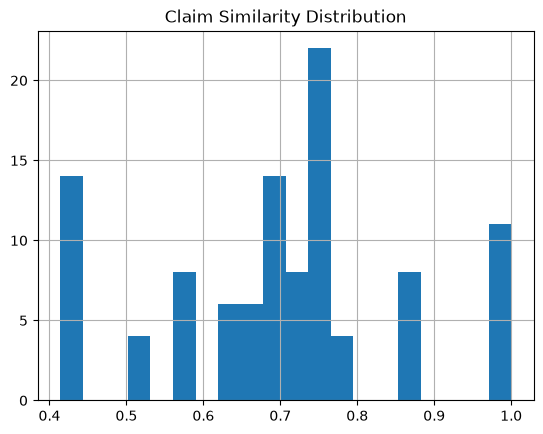

In [24]:
pairs_df["similarity"].hist(bins=20)

plt.title("Claim Similarity Distribution")

plt.show()

In [25]:
top_suspicious = pairs_df.sort_values(by="similarity", ascending=False).head(10)

In [26]:
top_suspicious

,claim_1,claim_2,claimant_1,claimant_2,similarity
59,CLM005,CLM015,Elizabeth Patel,Patricia Lopez,1.0
94,CLM010,CLM015,Julia Wilson,Patricia Lopez,1.0
54,CLM005,CLM010,Elizabeth Patel,Julia Wilson,1.0
51,CLM005,CLM007,Elizabeth Patel,Lisa Rich,1.0
71,CLM007,CLM010,Lisa Rich,Julia Wilson,1.0
76,CLM007,CLM015,Lisa Rich,Patricia Lopez,1.0
15,CLM002,CLM004,Douglas Lara,Jodi Reynolds MD,1.0
64,CLM006,CLM011,Kevin Paul,Patrick Harvey,1.0
11,CLM001,CLM013,Wendy Holland,Janice Zavala,1.0
82,CLM008,CLM014,Pamela Hayes,Misty Smith,1.0


In [27]:
network_edges = template_fraud[["claim_1", "claim_2", "similarity"]]

In [28]:
network_edges

,claim_1,claim_2,similarity
11,CLM001,CLM013,1.0
15,CLM002,CLM004,1.0
51,CLM005,CLM007,1.0
54,CLM005,CLM010,1.0
59,CLM005,CLM015,1.0
64,CLM006,CLM011,1.0
71,CLM007,CLM010,1.0
76,CLM007,CLM015,1.0
82,CLM008,CLM014,1.0
86,CLM009,CLM012,1.0


In [30]:
fraud_claims = claims_df[claims_df["fraud_label"] == 1]

In [31]:
fraud_claims[["claim_id", "fraud_label"]]

,claim_id,fraud_label
2,CLM003,1
5,CLM006,1
7,CLM008,1
8,CLM009,1
9,CLM010,1
10,CLM011,1


In [32]:
flagged_claims = set(
    template_fraud["claim_1"].tolist() + template_fraud["claim_2"].tolist()
)

flagged_claims

{'CLM001',
 'CLM002',
 'CLM004',
 'CLM005',
 'CLM006',
 'CLM007',
 'CLM008',
 'CLM009',
 'CLM010',
 'CLM011',
 'CLM012',
 'CLM013',
 'CLM014',
 'CLM015'}

In [33]:
template_fraud.to_csv("../data/template_fraud_candidates.csv", index=False)

In [35]:
template_fraud

,claim_1,claim_2,claimant_1,claimant_2,similarity,fraud_score
11,CLM001,CLM013,Wendy Holland,Janice Zavala,1.0,100.0
15,CLM002,CLM004,Douglas Lara,Jodi Reynolds MD,1.0,100.0
51,CLM005,CLM007,Elizabeth Patel,Lisa Rich,1.0,100.0
54,CLM005,CLM010,Elizabeth Patel,Julia Wilson,1.0,100.0
59,CLM005,CLM015,Elizabeth Patel,Patricia Lopez,1.0,100.0
64,CLM006,CLM011,Kevin Paul,Patrick Harvey,1.0,100.0
71,CLM007,CLM010,Lisa Rich,Julia Wilson,1.0,100.0
76,CLM007,CLM015,Lisa Rich,Patricia Lopez,1.0,100.0
82,CLM008,CLM014,Pamela Hayes,Misty Smith,1.0,100.0
86,CLM009,CLM012,Kendra Reyes,Stephanie Wood,1.0,100.0


In [34]:
network_edges.to_csv("../data/template_fraud_network.csv", index=False)

In [36]:
network_edges

,claim_1,claim_2,similarity
11,CLM001,CLM013,1.0
15,CLM002,CLM004,1.0
51,CLM005,CLM007,1.0
54,CLM005,CLM010,1.0
59,CLM005,CLM015,1.0
64,CLM006,CLM011,1.0
71,CLM007,CLM010,1.0
76,CLM007,CLM015,1.0
82,CLM008,CLM014,1.0
86,CLM009,CLM012,1.0
